## Figure 10

This is a standalone notebook; all simulations run locally in a few seconds.

In [1]:
from pathlib import Path

import numpy as np
from scipy.stats import pearsonr

import matplotlib as mpl
import matplotlib.pyplot as plt
import spiffyplots
from spiffyplots import MultiPanel
from matplotlib.colors import to_rgba
from cmcrameri import cm as cmc

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "axes.unicode_minus": False,})
mpl.rc('text.latex', preamble=r'\usepackage{cmbright}')

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())


def relu(x):
    return np.maximum(x, 0.0)

#### Directory setup

In [2]:
fig10_dir = repo_root / "figures" / "fig10"
fig10_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [3]:
cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_inh = '#0077B8'
color_initial = '0.65'

cmap_inhibition = cmc.oslo_r
cmap_weight_change = cmc.vik

linewidth = 1.0

#### Model parameters

In [4]:
SEED = 2026

# one E / one I circuit
alpha = 0.5
W_EI = 1.0
g_XI = 1.0
W_IE = alpha / ((1.0 - alpha) * W_EI + g_XI)

### Panel b: open-loop experiment

In [5]:
rule_I_FF = np.arange(0.0, 4.0, 0.01)
rule_inhibition = np.array([0.0, 0.2, 0.4, 0.6, 0.8])
hebb_threshold = 1.0
figsize_open_loop = (6*cm, 2*cm)

In [6]:
def bcp_weight_change(presynaptic_rate, I_FF, I_inh2):
    return presynaptic_rate * (alpha * I_FF - I_inh2)


def rate_weight_change(presynaptic_rate, postsynaptic_rate):
    return presynaptic_rate * (postsynaptic_rate - hebb_threshold)

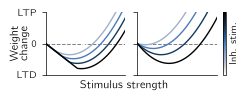

In [7]:
fig = MultiPanel(grid=[2], figsize=figsize_open_loop, labels=False)
inhibition_norm = mpl.colors.Normalize(vmin=rule_inhibition.min(), vmax=rule_inhibition.max())

for inhibitory_stimulus in rule_inhibition:
    color = cmap_inhibition(inhibition_norm(inhibitory_stimulus))
    r_E = relu(rule_I_FF - inhibitory_stimulus)
    fig.panels[0].plot(rule_I_FF, rate_weight_change(rule_I_FF, r_E), color=color, lw=linewidth)
    fig.panels[1].plot(rule_I_FF, 2 * bcp_weight_change(rule_I_FF, rule_I_FF, inhibitory_stimulus),
                       color=color, lw=linewidth)

for ax in fig.panels:
    ax.axhline(0, color='gray', lw=0.7 * linewidth, ls='dashed', zorder=-1)
    ax.set_ylim(-1, 1)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['LTD', 0, 'LTP'], fontsize=7)
    ax.set_xlim(0, 2)
    ax.set_xticks([])

fig.panels[0].set_ylabel('Weight\nchange', fontsize=8, labelpad=-9)
fig.panels[1].set_yticklabels([])
fig.fig.supxlabel('Stimulus strength', fontsize=8, y=-0.08)

colorbar = fig.fig.colorbar(mpl.cm.ScalarMappable(norm=inhibition_norm, cmap=cmap_inhibition),
                            ax=fig.panels, fraction=0.045, pad=0.04)
# vector gradient: a rasterized one shifts against its outline in the PDF
colorbar.solids.set_rasterized(False)
colorbar.set_ticks([])
colorbar.set_label('Inh. stim.', fontsize=7, labelpad=2)

plt.savefig(fig10_dir / 'b_open_loop.pdf', bbox_inches='tight')
plt.show()

### Panel d: closed-loop experiment

In [8]:
closed_loop_I_FF = 1.0
closed_loop_rate_max = 2.0
closed_loop_opto_max = 1.0
closed_loop_grid_size = 261
closed_loop_hebb_threshold = 1.0
figsize_closed_loop = (6*cm, 2.4*cm)

In [9]:
# balance condition without direct feed-forward input to I
W_IE_closed_loop = (alpha / (1.0 - alpha)) / W_EI

clamped_rate = np.linspace(1e-3, closed_loop_rate_max, closed_loop_grid_size)
opto_inhibition = np.linspace(-closed_loop_opto_max, closed_loop_opto_max, closed_loop_grid_size)
rate_grid, opto_grid = np.meshgrid(clamped_rate, opto_inhibition)

r_I_closed_loop = relu(W_EI * rate_grid + opto_grid)
I_inh2_closed_loop = W_IE_closed_loop * r_I_closed_loop
I_control = rate_grid - closed_loop_I_FF + I_inh2_closed_loop
I_exc_closed_loop = closed_loop_I_FF + I_control

dw_bcp_closed_loop = alpha * relu(I_exc_closed_loop) - I_inh2_closed_loop
dw_rate_closed_loop = rate_grid - closed_loop_hebb_threshold

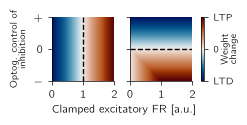

In [10]:
fig = MultiPanel(grid=[2], figsize=figsize_closed_loop, labels=False)
extent = [clamped_rate.min(), clamped_rate.max(), opto_inhibition.min(), opto_inhibition.max()]

for ax, dw in zip(fig.panels, [dw_rate_closed_loop, dw_bcp_closed_loop]):
    im = ax.imshow(dw / np.abs(dw).max(), origin='lower', extent=extent, aspect='auto',
                   cmap=cmap_weight_change, vmin=-1.0, vmax=1.0, interpolation='bilinear', rasterized=True)
    ax.set_xticks([0.0, 1, 2])
    ax.set_xticklabels(['0', '1', '2'])
    ax.set_yticks([-closed_loop_opto_max, 0.0, closed_loop_opto_max])

fig.panels[0].axvline(closed_loop_hebb_threshold, color='black', ls='--', lw=linewidth)
fig.panels[1].axhline(0, color='black', ls='--', lw=linewidth)
fig.panels[0].set_yticklabels(['−', '0', '+'])
fig.panels[1].set_yticklabels([])
fig.panels[0].set_ylabel('Optog. control of\ninhibition', fontsize=7, labelpad=5)
fig.fig.supxlabel(r'Clamped excitatory FR [a.u.]', fontsize=8, y=-0.12)

colorbar = fig.fig.colorbar(im, ax=fig.panels, fraction=0.046, pad=0.04)
colorbar.set_ticks([-1.0, 0.0, 1.0], labels=['LTD', '0', 'LTP'], fontsize=7)
colorbar.set_label('Weight\nchange', fontsize=7, labelpad=-9)
colorbar.solids.set_rasterized(False)

plt.savefig(fig10_dir / 'd_closed_loop.pdf', dpi=600, bbox_inches='tight')
plt.show()

### Panels e, f: receptive field plasticity of an example neuron

In [11]:
Nb_inputs = 180
theta = np.arange(Nb_inputs, dtype=float)
X = np.eye(Nb_inputs)

# initial receptive field
theta_0 = 50.0
w_gauss_amplitude = 0.5
w_gauss_sigma = 30.0
w_b = 1.3
w_rand_min = 0.0
w_rand_max = 0.0

# target receptive field
target_theta = 105.0
target_width = 10.0
target_amplitude = 1.3
target_baseline = 0.2

controller_gain = 5.0
learning_rate = 0.15
training_steps = 120

figsize_rf = (2*cm, 3.0*cm)

In [ ]:
def circular_gaussian(theta_values, center, sigma, amplitude=1.0):
    angular_distance = (np.asarray(theta_values) - np.asarray(center) + 90.0) % 180.0 - 90.0
    return amplitude * np.exp(-0.5 * (angular_distance / sigma) ** 2)


def initialize_receptive_fields(theta_values, centers, rng, sigma=w_gauss_sigma, amplitude=w_gauss_amplitude,
                                baseline=w_b, noise_min=w_rand_min, noise_max=w_rand_max):
    centers = np.atleast_1d(np.asarray(centers, dtype=float))
    gaussian = circular_gaussian(np.asarray(theta_values)[:, None], centers[None, :], sigma, amplitude)
    noise = rng.uniform(noise_min, noise_max, size=gaussian.shape)
    return np.maximum(baseline + gaussian + noise, 0.0)  # [orientations, neurons]


def steady_state(weights, targets=None, controller_gains=None):
    # fixed point of r_E = I_FF - W_IE r_I, r_I = g_XI I_FF + W_EI r_E - k_p (y - r_E);
    # r_E is clipped at I_FF where the I neuron is silent
    I_FF = X @ np.asarray(weights)

    if targets is None:
        gain = 0.0
        target_values = np.zeros_like(I_FF)
    else:
        gain = controller_gain if controller_gains is None else np.asarray(controller_gains)
        target_values = np.broadcast_to(np.asarray(targets), I_FF.shape)

    r_E = np.clip(((1.0 - W_IE * g_XI) * I_FF + W_IE * gain * target_values)
                  / (1.0 + W_IE * (W_EI + gain)), 0.0, I_FF)
    r_I = np.maximum((I_FF - r_E) / W_IE, 0.0)
    I_inh2 = W_IE * r_I

    return {'r_E': r_E, 'r_I': r_I, 'I_FF': I_FF, 'I_inh2': I_inh2,
            'balance_error': alpha * I_FF - I_inh2}


def run_learning(initial_weights, targets, controller_gains=None):
    # one BCP update per presentation of all orientations;
    # 'early' is the second presentation, after one update
    weights = np.asarray(initial_weights, dtype=float).copy()
    initial = steady_state(weights)

    for step in range(training_steps):
        training_state = steady_state(weights, targets, controller_gains)
        if step == 1:
            early = training_state
        weights = np.maximum(weights + learning_rate * X.T @ training_state['balance_error'], 0.0)

    return {'initial': initial, 'early': early, 'final': steady_state(weights)}

In [13]:
example_weights = initialize_receptive_fields(theta, theta_0, np.random.default_rng(SEED))[:, 0]
example_target = target_baseline + circular_gaussian(theta, target_theta, target_width, target_amplitude)
example = run_learning(example_weights, example_target)

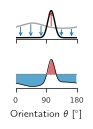

In [14]:
fig, axes = plt.subplots(2, 1, figsize=figsize_rf, sharex=True, gridspec_kw={'hspace': 0.25})

r_E_before = example['initial']['r_E']
r_E_after = example['final']['r_E']
delta_r_E = r_E_after - r_E_before

axes[0].plot(theta, r_E_before, color=color_initial, lw=linewidth)
axes[0].plot(theta, r_E_after, color='black', lw=linewidth)
for orientation in np.linspace(15, 165, 6).astype(int):
    axes[0].annotate('', xy=(orientation, r_E_after[orientation]), xytext=(orientation, r_E_before[orientation]),
                     arrowprops={'arrowstyle': '->', 'color': color_exc if delta_r_E[orientation] >= 0.0 else color_inh,
                                 'lw': 0.6, 'mutation_scale': 5, 'shrinkA': 1, 'shrinkB': 1})

axes[1].axhline(0, color='gray', lw=0.5, ls='dashed', zorder=10)
axes[1].fill_between(theta, 0, delta_r_E, where=delta_r_E >= 0.0, color=color_exc, alpha=0.65,
                     interpolate=True, linewidth=0.0)
axes[1].fill_between(theta, 0, delta_r_E, where=delta_r_E < 0.0, color=color_inh, alpha=0.65,
                     interpolate=True, linewidth=0.0)
axes[1].plot(theta, delta_r_E, color='black', lw=0.5)

for ax in axes:
    ax.set_xlim(0, 179)
    ax.set_xticks([0, 90, 180])
    ax.yaxis.set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=6)
axes[1].set_xlabel(r'Orientation $\theta$ [$^\circ$]', fontsize=7)

plt.savefig(fig10_dir / 'e_rf_change.pdf', bbox_inches='tight')
plt.show()

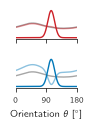

In [15]:
fig, axes = plt.subplots(2, 1, figsize=figsize_rf, sharex=True, gridspec_kw={'hspace': 0.25})

states = ['initial', 'early', 'final']
for ax, current, color in [(axes[0], 'I_FF', color_exc), (axes[1], 'I_inh2', color_inh)]:
    for state, c in zip(states, [color_initial, to_rgba(color, 0.45), color]):
        ax.plot(theta, example[state][current], color=c, lw=linewidth)

for ax in axes:
    ax.set_xlim(0, 179)
    ax.set_xticks([0, 90, 180])
    ax.yaxis.set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=6)
axes[1].set_xlabel(r'Orientation $\theta$ [$^\circ$]', fontsize=7)

plt.savefig(fig10_dir / 'f_currents.pdf', bbox_inches='tight')
plt.show()

### Panel h: predictors of the receptive field change

In [16]:
N_assemblies = 100
w_gauss_amplitude_range = (0.7, 1.3)
w_gauss_sigma_range = (20.0, 40.0)
w_b_range = (0.7, 1.3)
w_noise_range = (-0.3, 0.3)
target_offset_range = (0.0, 90.0)
target_width_range = (7.0, 15.0)
target_amplitude_range = (1.5, 2.5)
controller_gain_range = (1, 3)

figsize_predictors = (3.5*cm, 2.4*cm)

In [17]:
rng = np.random.default_rng(SEED + 1)

initial_centers = rng.uniform(0.0, 180.0, size=N_assemblies)
target_directions = rng.choice([-1.0, 1.0], size=N_assemblies)
target_offsets = rng.uniform(*target_offset_range, size=N_assemblies)
target_centers = (initial_centers + target_directions * target_offsets) % 180.0

initial_amplitudes = rng.uniform(*w_gauss_amplitude_range, size=N_assemblies)
initial_widths = rng.uniform(*w_gauss_sigma_range, size=N_assemblies)
initial_baselines = rng.uniform(*w_b_range, size=N_assemblies)
population_weights = initialize_receptive_fields(
    theta, initial_centers, rng, sigma=initial_widths, amplitude=initial_amplitudes,
    baseline=initial_baselines, noise_min=w_noise_range[0], noise_max=w_noise_range[1])

target_widths = rng.uniform(*target_width_range, size=N_assemblies)
target_amplitudes = rng.uniform(*target_amplitude_range, size=N_assemblies)
controller_gains = rng.uniform(*controller_gain_range, size=N_assemblies)
population_targets = target_baseline + circular_gaussian(
    theta[:, None], target_centers[None, :], target_widths, target_amplitudes)

population = run_learning(population_weights, population_targets, controller_gains)
rf_change = population['final']['r_E'] - population['initial']['r_E']  # [orientations, assemblies]

predictors = {
    'Initial $r_\mathrm{E}$': population['initial']['r_E'],
    'Early training $r_\mathrm{E}$': population['early']['r_E'],
    'Early training $r_\mathrm{I}$': population['early']['r_I'],
    r'$\Delta r_\mathrm{I}$': population['early']['r_I'] - population['initial']['r_I'],
}
r2_by_predictor = {
    name: np.array([pearsonr(p[:, n], rf_change[:, n]).statistic ** 2 for n in range(N_assemblies)])
    for name, p in predictors.items()
}

for name, r2 in r2_by_predictor.items():
    print(f'{name:26s}: r^2 = {r2.mean():.3f} +- {r2.std():.3f}')

Initial $r_E$             : r^2 = 0.254 +- 0.185
Early training $r_E$      : r^2 = 0.357 +- 0.210
Early training $r_I$      : r^2 = 0.583 +- 0.267
$\Delta r_I$              : r^2 = 0.996 +- 0.009


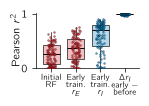

In [18]:
predictor_colors = [color_exc, color_exc, color_inh, color_inh]
predictor_ticklabels = [
    'Initial\nRF',
    'Early\ntrain.\n' + r'$r_\mathrm{E}$',
    'Early\ntrain.\n' + r'$r_\mathrm{I}$',
    r'$\Delta r_\mathrm{I}$' + '\n' + r'early $-$' + '\n' + 'before',
]
box_width = 0.7
jitter_width = 0.34
point_size = 2

fig, ax = plt.subplots(figsize=figsize_predictors)
for position, (r2, color) in enumerate(zip(r2_by_predictor.values(), predictor_colors)):
    ax.boxplot([r2], positions=[position], widths=box_width, patch_artist=True, showfliers=False, showcaps=False,
               boxprops={'facecolor': to_rgba(color, 0.28), 'edgecolor': 'black', 'linewidth': 0.45},
               whiskerprops={'color': 'black', 'linewidth': 0.45},
               medianprops={'color': 'black', 'linewidth': 0.7}, zorder=2)
    ax.scatter(np.linspace(position - jitter_width / 2, position + jitter_width / 2, len(r2)), r2,
               s=point_size, facecolor=to_rgba(color, 0.72), edgecolor='black', linewidth=0.125, zorder=3)

ax.set_xticks(np.arange(len(predictor_ticklabels)))
ax.set_xticklabels(predictor_ticklabels, rotation=0, ha='center', fontsize=6, linespacing=0.85)
ax.tick_params(axis='x', pad=1)
ax.set_xlim(-0.6, len(predictor_ticklabels) - 0.4)
ax.set_ylim(0.0, 1.02)
ax.set_yticks([0.0, 1.0])
ax.set_ylabel(r'Pearson $r^2$', labelpad=0)

plt.savefig(fig10_dir / 'h_predictors.pdf', bbox_inches='tight')
plt.show()